# Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load dataset

In [19]:
df = pd.read_csv('../dataset/train-test.csv')  # update filename
print(df.shape)
df.head(10)

(48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
5,TR-000006,Phoenix,Corpus Christi,28.75668,-115.87725,28.61374,-95.89569,1396.4,Flatbed,17018.0,2025-01-01,0.95167,1.92983,2676.98
6,TR-000007,Fresno,San Antonio,33.07921,-119.79528,29.50969,-98.40059,1502.6,Dry Van,19112.0,2025-01-01,0.95696,1.82074,2718.54
7,TR-000008,San Francisco,Kansas City,35.19670,-121.69849,39.41104,-91.12450,1976.9,Dry Van,29169.0,2025-01-01,0.97818,1.78430,3522.92
8,TR-000009,Bakersfield,Montgomery,33.28832,-116.67935,31.37602,-86.10743,2027.7,Dry Van,35018.0,2025-01-01,0.96534,1.79522,3675.27
9,TR-000010,Albuquerque,Phoenix,35.39918,-109.59792,28.75668,-115.87725,717.1,Flatbed,34671.0,2025-01-01,0.98475,2.17079,1578.83


# Data types and basic info

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [21]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


# missing counts for each column (numuraical)

In [22]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df)

              missing_count  missing_pct
market_index            374     0.779167
weight                  300     0.625000
delivery                  0     0.000000
pickup_lat                0     0.000000
load_id                   0     0.000000
pickup                    0     0.000000
delivery_lat              0     0.000000
pickup_lon                0     0.000000
distance                  0     0.000000
delivery_lon              0     0.000000
equipment                 0     0.000000
date                      0     0.000000
quote_signal              0     0.000000
posted_rate               0     0.000000


# Drop null rows entirely

In [24]:
before = len(df)

df = df.dropna(subset=['market_index', 'weight'])

after = len(df)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")
print(f"% removed: {((before - after) / before) * 100:.2f}%")
print("\nMissing values remaining:\n", df.isnull().sum().sum())

Rows removed: 0
Rows remaining: 47327
% removed: 0.00%

Missing values remaining:
 0


# Investigate outliers using box plot

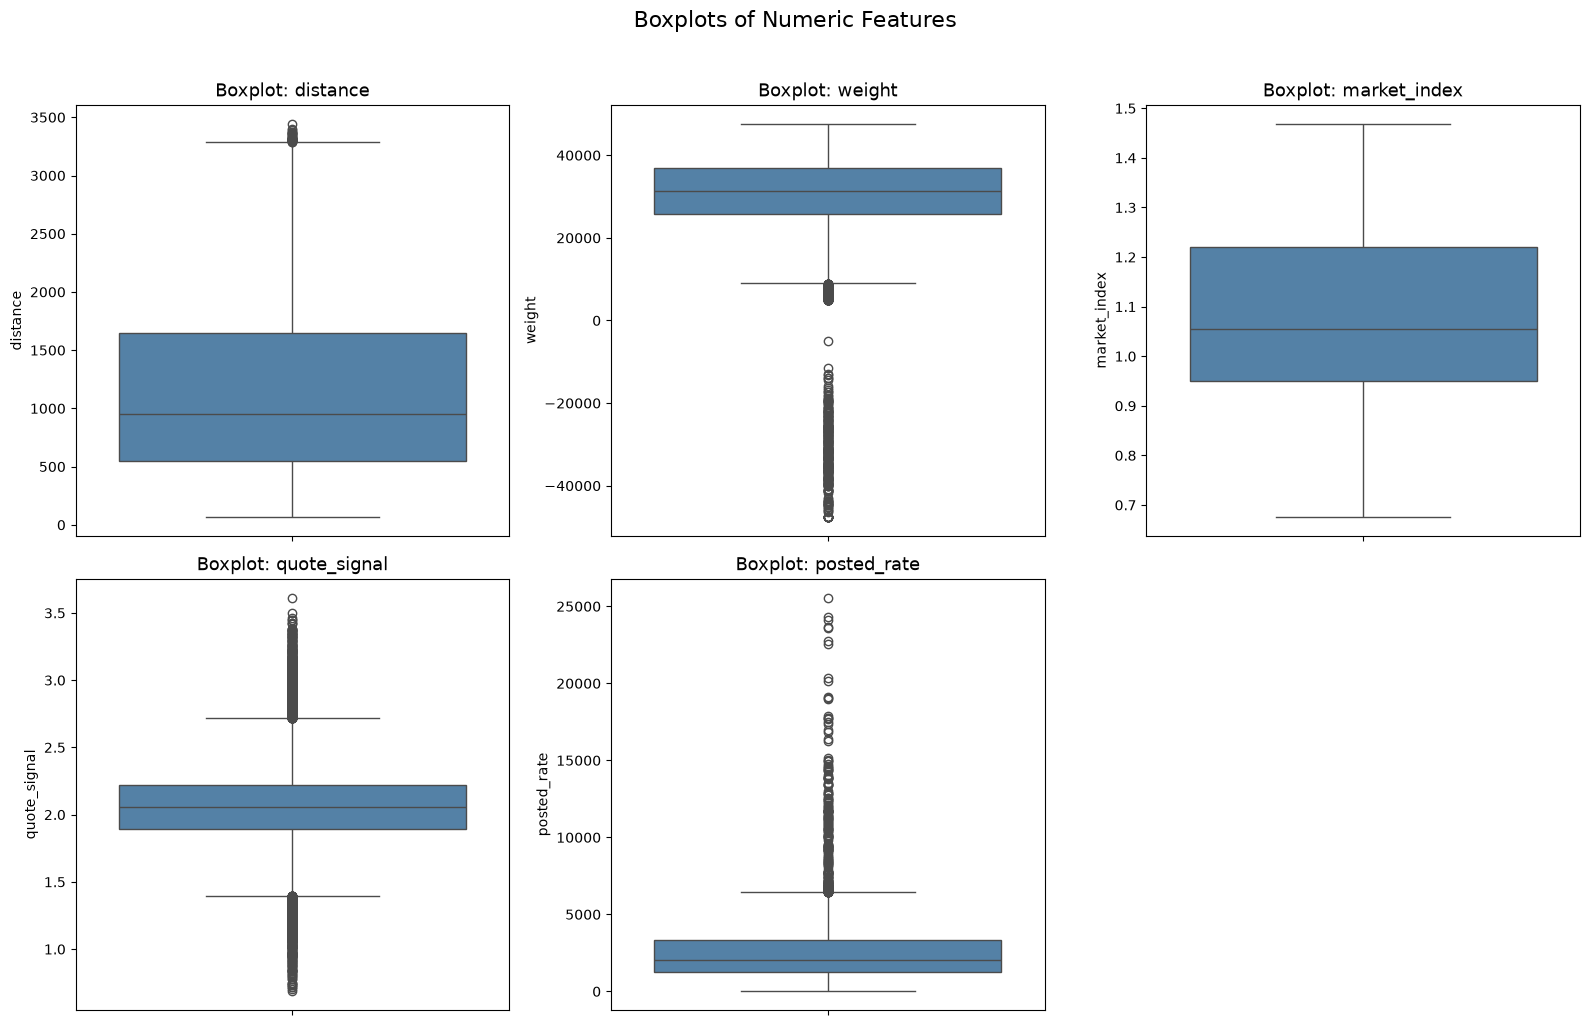

In [26]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}', fontsize=13)
    axes[i].set_ylabel(col)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Boxplots of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Check negative weights
print("Negative weight rows:", (df['weight'] < 0).sum())
print(df[df['weight'] < 0][['load_id','weight','equipment','distance']].head(10))

Negative weight rows: 289
        load_id   weight equipment  distance
68    TR-000069 -36559.0    Reefer    1334.2
204   TR-000205 -26670.0   Dry Van     496.2
206   TR-000207 -20003.0    Reefer     411.3
225   TR-000226 -23981.0    Reefer    1317.4
376   TR-000377 -41397.0   Dry Van    1331.1
446   TR-000447 -37215.0    Reefer    2438.3
495   TR-000496 -31214.0   Dry Van     715.9
641   TR-000642 -41023.0   Dry Van     582.4
806   TR-000807 -28320.0   Dry Van     676.1
1093  TR-001094 -25153.0   Dry Van    1058.5


In [32]:
# Are high rates tied to long distances?
high_rate = df[df['posted_rate'] > 7000]
print(f"High rate rows: {len(high_rate)}")
print(high_rate[['load_id','distance','weight','equipment','posted_rate']].head(10))


High rate rows: 171
        load_id  distance   weight equipment  posted_rate
469   TR-000470    2154.3  22509.0   Dry Van     10854.69
1329  TR-001330    1190.5  28538.0   Dry Van      7100.73
1466  TR-001467    2786.0  30322.0    Reefer     24140.21
1949  TR-001950    2794.2  35166.0    Reefer     13918.00
2030  TR-002031    1247.6  46843.0   Dry Van     10270.54
2221  TR-002222    1166.1  42165.0   Flatbed     11210.34
2223  TR-002224    1344.4  24751.0   Dry Van     12100.18
2514  TR-002515    1006.5  19892.0   Dry Van      9313.19
2662  TR-002663    1951.9  29933.0   Dry Van     10436.26
3028  TR-003029    1489.5  34450.0    Reefer      7679.26


# Outlier counts via IQR

In [13]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | lower={lower:.2f}, upper={upper:.2f}")

distance: 32 outliers | lower=-1092.29, upper=3288.21
weight: 424 outliers | lower=8973.00, upper=53845.00
market_index: 0 outliers | lower=0.54, upper=1.62
quote_signal: 1956 outliers | lower=1.40, upper=2.72
posted_rate: 260 outliers | lower=-1867.24, upper=6449.54


# Drop negative weight and negative rate rows

In [14]:
before = len(df)

df = df[df['weight'] > 0]
df = df[df['posted_rate'] > 0]

after = len(df)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")
print(f"% removed: {((before - after) / before) * 100:.2f}%")

Rows removed: 592
Rows remaining: 47408
% removed: 1.23%


In [15]:
print("Negative weights:", (df['weight'] < 0).sum())
print("Negative posted_rate:", (df['posted_rate'] < 0).sum())
print("\nShape after cleaning:", df.shape)

Negative weights: 0
Negative posted_rate: 0

Shape after cleaning: (47408, 14)


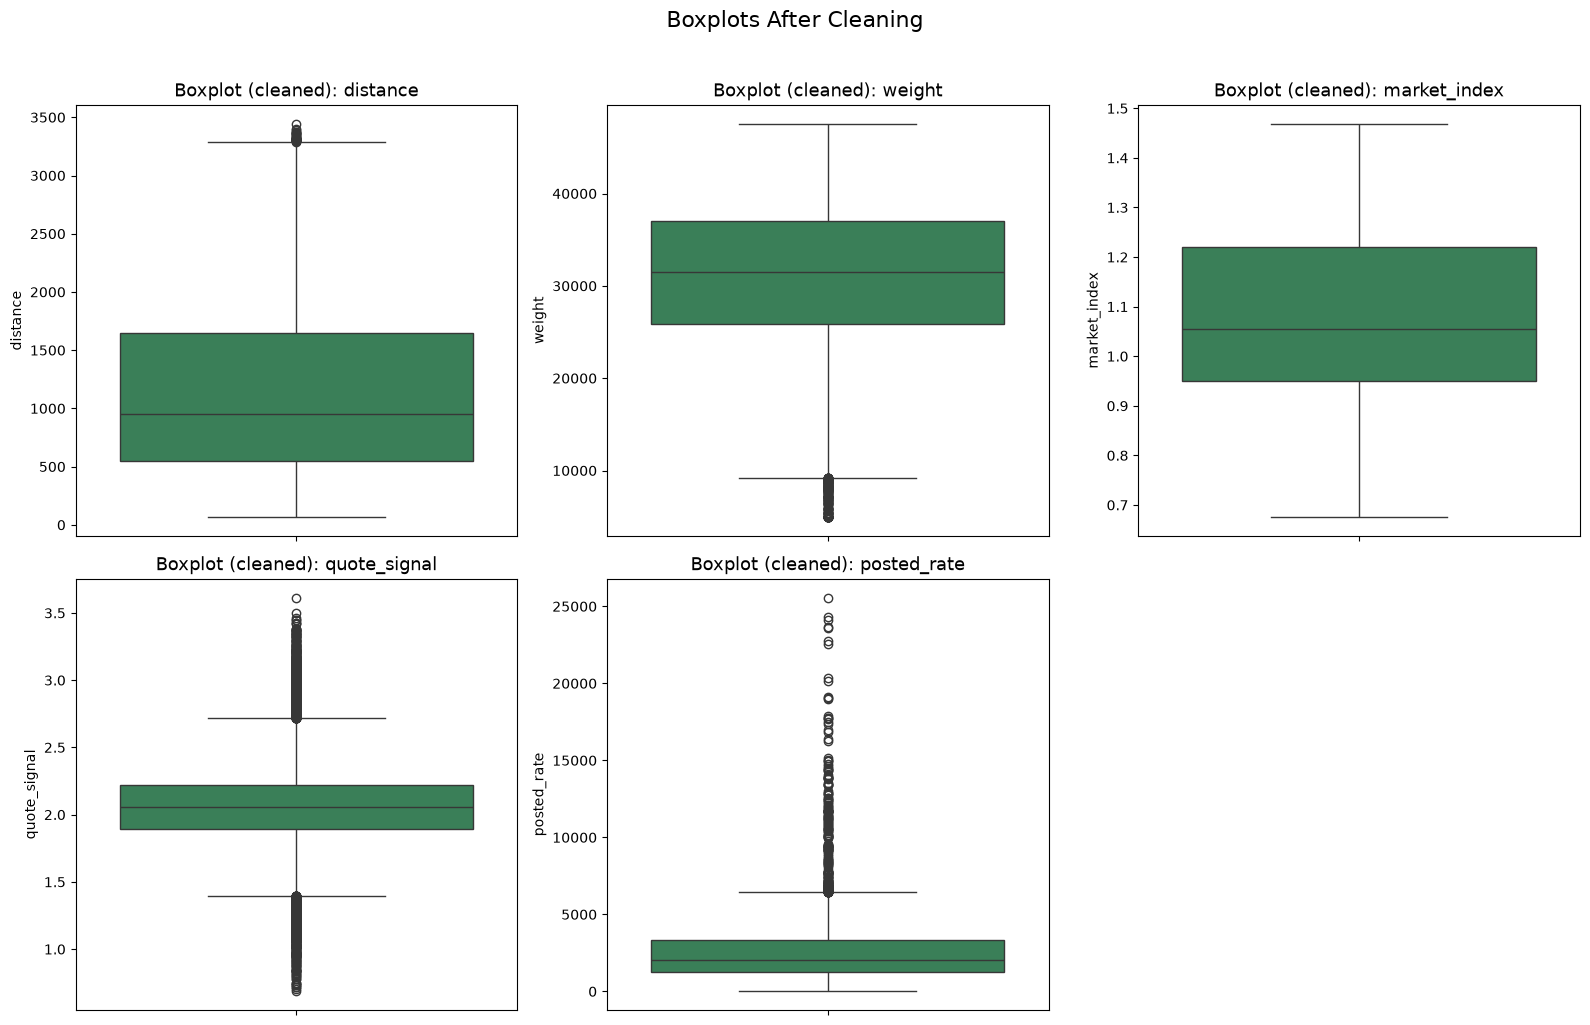

In [16]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='seagreen')
    axes[i].set_title(f'Boxplot (cleaned): {col}', fontsize=13)

axes[-1].set_visible(False)
plt.suptitle('Boxplots After Cleaning', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()